In [35]:
from google.colab import drive
drive.mount('/content/drive/')

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


# **Step 1: Data Triage & Statistical Setup**

In [36]:
import pandas as pd
import numpy as np

# 1) Loading the Data
file_path = '/content/drive/MyDrive/Data Science Projects/Credit Risk Detection/previous_application.csv'
data = pd.read_csv(file_path, sep=',');
df = data.copy()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1670214 entries, 0 to 1670213
Data columns (total 37 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   SK_ID_PREV                   1670214 non-null  int64  
 1   SK_ID_CURR                   1670214 non-null  int64  
 2   NAME_CONTRACT_TYPE           1670214 non-null  object 
 3   AMT_ANNUITY                  1297979 non-null  float64
 4   AMT_APPLICATION              1670214 non-null  float64
 5   AMT_CREDIT                   1670213 non-null  float64
 6   AMT_DOWN_PAYMENT             774370 non-null   float64
 7   AMT_GOODS_PRICE              1284699 non-null  float64
 8   WEEKDAY_APPR_PROCESS_START   1670214 non-null  object 
 9   HOUR_APPR_PROCESS_START      1670214 non-null  int64  
 10  FLAG_LAST_APPL_PER_CONTRACT  1670214 non-null  object 
 11  NFLAG_LAST_APPL_IN_DAY       1670214 non-null  int64  
 12  RATE_DOWN_PAYMENT            774370 non-nu

In [37]:
# 2) Selecting Columns for Statistical Roadmap
columns_to_keep = [
    'SK_ID_CURR',
    'AMT_CREDIT',
    'NAME_CONTRACT_STATUS',
    'NAME_CLIENT_TYPE',
    'CHANNEL_TYPE'
]

stats_df = df[columns_to_keep].copy()

# 3) Cleaning the Subset
stats_df = stats_df.dropna(subset=['AMT_CREDIT'])

# 4) Checking the New Version of DataFrame
print(f"Original Shape: {df.shape}")
print(f"Cleaned Stats shape: {stats_df.shape}\n")
stats_df.head()

Original Shape: (1670214, 37)
Cleaned Stats shape: (1670213, 5)



,SK_ID_CURR,AMT_CREDIT,NAME_CONTRACT_STATUS,NAME_CLIENT_TYPE,CHANNEL_TYPE
0,271877,17145.0,Approved,Repeater,Country-wide
1,108129,679671.0,Approved,Repeater,Contact center
2,122040,136444.5,Approved,Repeater,Credit and cash offices
3,176158,470790.0,Approved,Repeater,Credit and cash offices
4,202054,404055.0,Refused,Repeater,Credit and cash offices


# Details about Selected Column Names

* **SK_ID_CURR** - IDs
* **AMT_CREDIT** - Asked amounts
* **NAME_CONTRACT_STATUS** - Statuses of the contract
* **NAME_CLIENT_TYPE** - Client types
* **CHANNEL_TYPE** - Locations of application

# **Step 2: Bayesian Probability**

In [38]:
# 1) Calculating P(Refused): The Prior
total_applications = len(stats_df)
refused_applications = len(stats_df[stats_df['NAME_CONTRACT_STATUS'] == 'Refused'])
p_refused = refused_applications / total_applications

# 2) Calculating P(New): The Evidence
new_clients = len(stats_df[stats_df['NAME_CLIENT_TYPE'] == 'New'])
p_new = new_clients / total_applications

# 3) Calcualting P(New | Refused): The Likelihood
# 3.1) Filtering the Frame
refused_df = stats_df[stats_df['NAME_CONTRACT_STATUS'] == 'Refused']
# 3.2) Finding the Number of Refused New Clients
new_given_refused = len(refused_df[refused_df['NAME_CLIENT_TYPE'] == 'New'])
p_new_given_refused = new_given_refused / len(refused_df)

# 4) Calculating P(Refused | New): The Prosterior (Bayes' Theorem)
p_refused_given_new = (p_new_given_refused * p_refused) / p_new

# 5) Displaying the Results
print(f"1. The Prior P(Refused): {p_refused: .4f} ({p_refused*100:.2f}%)")
print(f"2. Evidence P(New): {p_new:.4f} ({p_new*100:.2f}%)")
print(f"3. The Likelihood P(New | Refused): {p_new_given_refused:.4f} ({p_new_given_refused*100:.2f}%)")
print("-" * 40)
print(f"Bayesian Prosterior P(Refused | New): {p_refused_given_new:.4f} ({p_refused_given_new*100:2f}%)")

1. The Prior P(Refused):  0.1740 (17.40%)
2. Evidence P(New): 0.1804 (18.04%)
3. The Likelihood P(New | Refused): 0.0496 (4.96%)
----------------------------------------
Bayesian Prosterior P(Refused | New): 0.0479 (4.788577%)


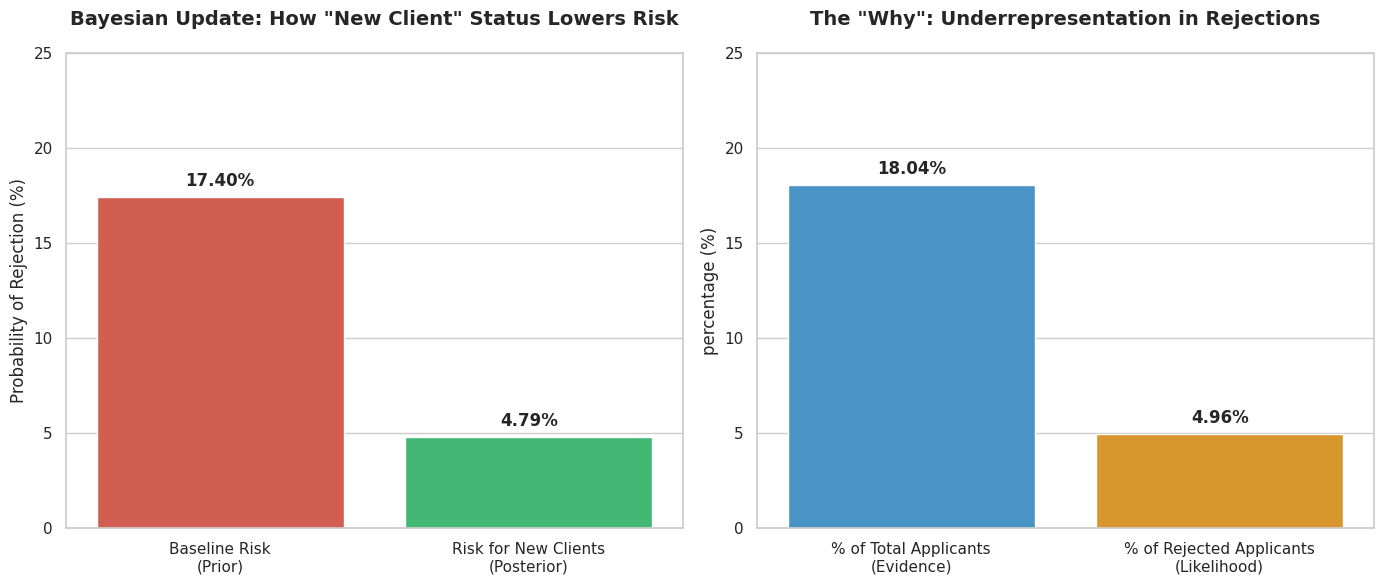

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

prior = round(p_refused * 100, 2)
evidence = round(p_new * 100, 2)
likelihood = round(p_new_given_refused *100, 2)
posterior = round(p_refused_given_new * 100, 2)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.barplot(x=['Baseline Risk\n(Prior)', 'Risk for New Clients\n(Posterior)'],
            y=[prior, posterior],
            palette=['#e74c3c', '#2ecc71'], ax=axes[0],
            hue=['Baseline Risk\n(Prior)', 'Risk for New Clients\nProsterior'], legend = False)
axes[0].set_title('Bayesian Update: How "New Client" Status Lowers Risk', fontsize=14, fontweight='bold', pad=20)
axes[0].set_ylabel('Probability of Rejection (%)', fontsize=12)
axes[0].set_ylim(0, 25)

for p in axes[0].patches:
  axes[0].annotate(f"{p.get_height():.2f}%",
                   (p.get_x() + p.get_width() / 2., p.get_height()),
                   ha='center', va='bottom', fontsize=12, fontweight='bold', xytext=(0, 5), textcoords='offset points')

sns.barplot(x=['% of Total Applicants\n(Evidence)', '% of Rejected Applicants\n(Likelihood)'],
            y=[evidence, likelihood],
            palette=['#3498db', '#f39c12',], ax=axes[1],
            hue=['% of Total Applicants\n(Evidence)', '% of Rejected Applicants\n(Likelihood)'], legend = False)
axes[1].set_title('The "Why": Underrepresentation in Rejections', fontsize=14, fontweight='bold', pad=20)
axes[1].set_ylabel('percentage (%)', fontsize=12)
axes[1].set_ylim(0, 25)

for p in axes[1].patches:
  axes[1].annotate(f"{p.get_height():.2f}%",
                   (p.get_x() + p.get_width() / 2., p.get_height()),
                   ha='center', va='bottom', fontsize=12, fontweight='bold', xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.show()

# **Step 3: Hypothesis Testing & T-Tests (The A/B Test Math)**

In [40]:
from scipy import stats

new_clients_df = stats_df[stats_df['NAME_CLIENT_TYPE'] == 'New']
repeater_clients_df = stats_df[stats_df['NAME_CLIENT_TYPE'] == 'Repeater']

new_credit = new_clients_df['AMT_CREDIT'].dropna()
repeater_credit = repeater_clients_df['AMT_CREDIT'].dropna()

mean_new = new_credit.mean()
mean_repeater = repeater_credit.mean()

t_stat, p_value = stats.ttest_ind(new_credit, repeater_credit, equal_var=False)

print(f"Mean AMT_CREDIT for New: {mean_new:.2f}")
print(f"Mean AMT_CREDIT for Repeater: {mean_repeater:.2f}")
print(f"T-Statistics: {t_stat:.4f}")
print(f"P-Value: {p_value}")

Mean AMT_CREDIT for New: 106273.49
Mean AMT_CREDIT for Repeater: 218560.05
T-Statistics: -268.5134
P-Value: 0.0


/tmp/ipython-input-1137833585.py:11: UserWarning: 
The palette list has fewer values (2) than needed (4) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(data=stats_df,


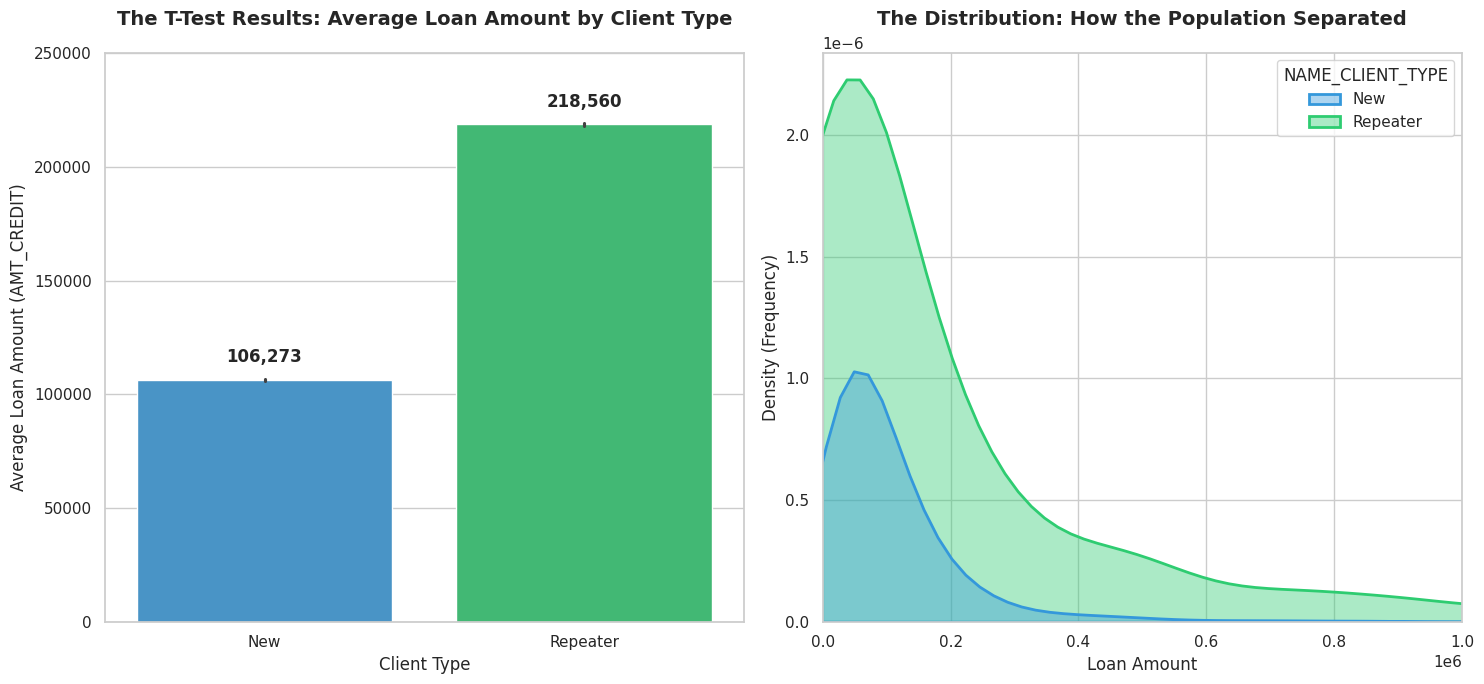

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

ttest_df = stats_df[stats_df['NAME_CLIENT_TYPE'].isin(['New', 'Repeater'])]

fig, axes = plt.subplots(1, 2, figsize=(15, 7))

# Panel 1: The Manager View (Bar Chart of Means)
sns.barplot(data=stats_df,
            x='NAME_CLIENT_TYPE',
            y='AMT_CREDIT',
            palette=['#2ecc71', '#3498db'],
            estimator='mean',
            ax=axes[0],
            hue='NAME_CLIENT_TYPE',
            legend=False,
            order=['New', 'Repeater'])

axes[0].set_title('The T-Test Results: Average Loan Amount by Client Type', fontsize=14, fontweight='bold', pad=20)
axes[0].set_ylabel('Average Loan Amount (AMT_CREDIT)', fontsize=12)
axes[0].set_xlabel('Client Type', fontsize=12)
axes[0].set_ylim(0, 250000)

#Actual Numbers on Top of the Bars
for p in axes[0].patches:
  axes[0].annotate(f'{p.get_height():,.0f}',
                   (p.get_x() + p.get_width() / 2., p.get_height()),
                   ha='center', va='bottom', fontsize=12, fontweight='bold', xytext=(0, 10), textcoords='offset points')

# Panel 2: The "Scientist" View (Distribution)
sample_df = ttest_df.sample(min(50000, len(ttest_df)), random_state=42)

sns.kdeplot(data=sample_df,
            x='AMT_CREDIT',
            hue='NAME_CLIENT_TYPE',
            fill=True,
            palette=['#3498db', '#2ecc71'],
            alpha=0.4,
            linewidth=2,
            ax=axes[1],
            hue_order=['New', 'Repeater'],
            bw_adjust=2)

axes[1].set_title('The Distribution: How the Population Separated', fontsize=14, fontweight='bold', pad=20)
axes[1].set_ylabel('Density (Frequency)', fontsize=12)
axes[1].set_xlabel('Loan Amount', fontsize=12)
axes[1].set_xlim(0, 1000000)

plt.tight_layout()
plt.show()

# **Step 4: Chi-Square Tests for Categorical Risk**

In [53]:
import pandas as pd
from scipy.stats import chi2_contingency

contingency_table = pd.crosstab(stats_df['CHANNEL_TYPE'], stats_df['NAME_CONTRACT_STATUS'])

print("--- Observed Contingency Table ---")
print(contingency_table)
print("\n")

chi2_stat, p_val, dof, expected = chi2_contingency(contingency_table)

print(f"Chi-Square Statistic: {chi2_stat:.4f}")
print(f"P-Value: {p_val}")
print(f"Degree of Freedom: {dof}")

--- Observed Contingency Table ---
NAME_CONTRACT_STATUS        Approved  Canceled  Refused  Unused offer
CHANNEL_TYPE                                                         
AP+ (Cash loan)                31231      3711    22099             5
Car dealer                       286        44      122             0
Channel of corporate sales      2649       136     3365             0
Contact center                 25220     30511    15566             0
Country-wide                  402786      1782    65762         24359
Credit and cash offices       289056    279973   150450           489
Regional / Local               96417        95    11326           690
Stone                         189135        67    21988           893


Chi-Square Statistic: 550551.9668
P-Value: 0.0
Degree of Freedom: 21


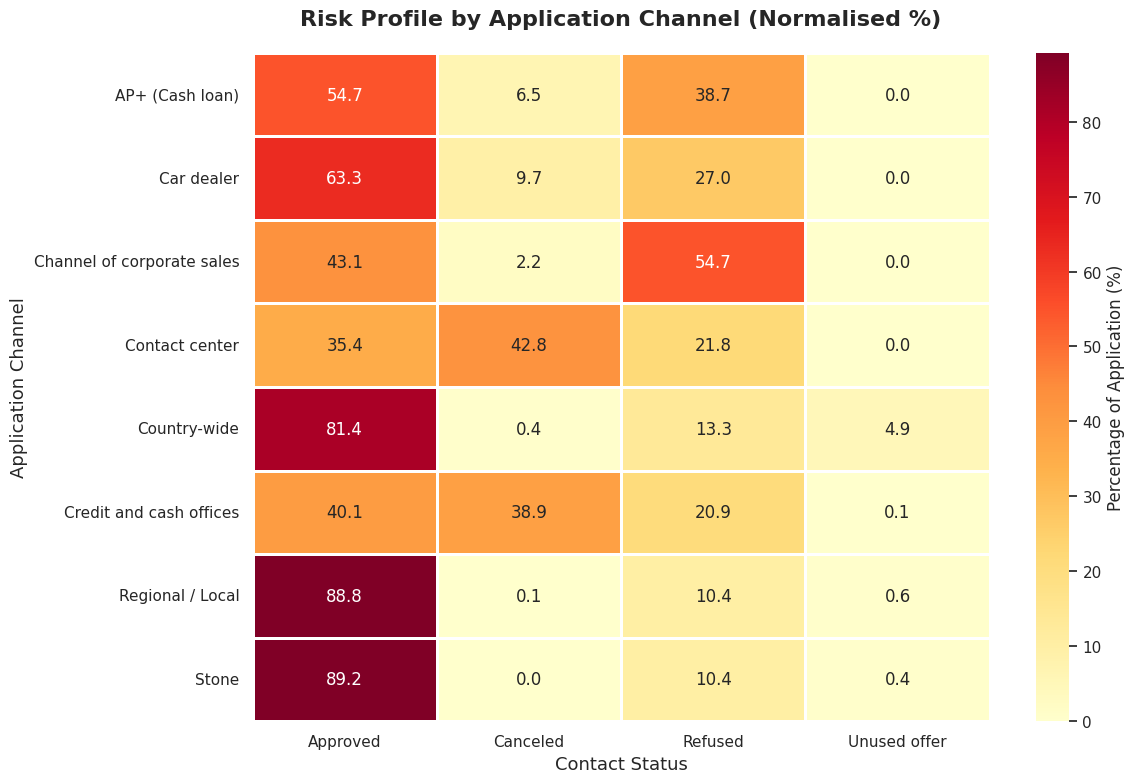

In [57]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

contingency_pct = pd.crosstab(stats_df['CHANNEL_TYPE'], stats_df['NAME_CONTRACT_STATUS'], normalize='index') * 100

plt.figure(figsize=(12, 8))
sns.set_theme(style='white')

sns.heatmap(contingency_pct,
            annot=True,
            fmt=".1f",
            cmap='YlOrRd',
            linewidth=1,
            cbar_kws={'label': 'Percentage of Application (%)'})

plt.title('Risk Profile by Application Channel (Normalised %)', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('Application Channel', fontsize=13)
plt.xlabel('Contact Status', fontsize=13)

plt.yticks(rotation=0)

plt.tight_layout()
plt.show()